# MediciMess Phase 1: Original Dataset Analysis

This notebook profiles the original Git-tracked dataset of 80,230 transactions and validates its double-entry accounting.

In [2]:
from decimal import Decimal
from pathlib import Path

import pandas as pd

csv_candidates = [
    Path("medici_transactions.csv"),
    Path("../medici_transactions.csv"),
]
csv_path = next((path for path in csv_candidates if path.exists()), None)
if csv_path is None:
    raise FileNotFoundError("Could not find medici_transactions.csv")

df = pd.read_csv(
    csv_path,
    dtype={
        "debit_amount": "string",
        "credit_amount": "string",
        "credit_amount_2": "string",
    },
    parse_dates=["date"],
)

print(f"Loaded {len(df):,} transactions from {csv_path.resolve()}")
display(df.head())

Loaded 80,230 transactions from /Users/hakeem/Projects/MediciMess_Charlie/medici_transactions.csv


,branch,counterparty,credit_account,credit_account_2,credit_amount,credit_amount_2,currency,date,debit_account,debit_amount,description,id,type
0,Florence,Republic of Florence,Cash,NaN,82833.66,<NA>,florin,1390-01-01,Loans Receivable - Government,82833.66,Emergency war financing for Florence defense,1,war_financing
1,Florence,Republic of Florence,Cash,NaN,124432.65,<NA>,florin,1390-01-01,Loans Receivable - Government,124432.65,Loan to Venice for Lombardy Wars operations,2,war_financing
2,Bruges,Gold Merchant,Cash,NaN,42534.83,<NA>,florin,1390-01-01,Loans Receivable,42534.83,Loan issued to Gold Merchant from Bruges branch,3,loan_issuance
3,Florence,Republic of Florence,Cash,NaN,1617678.46,<NA>,florin,1390-01-01,Loans Receivable - Government,1617678.46,War financing for Florentine operations agains...,4,war_financing
4,Florence,Republic of Florence,Cash,NaN,27742.84,<NA>,florin,1390-01-01,Loans Receivable - Government,27742.84,Loan to Venice for Lombardy Wars operations,5,war_financing


## Accounting validation

Convert money to `Decimal`, treating a missing secondary credit as zero. Each row must satisfy `debit_amount = credit_amount + credit_amount_2`.

In [3]:
amount_columns = ["debit_amount", "credit_amount", "credit_amount_2"]
for column in amount_columns:
    df[column] = df[column].map(
        lambda value: Decimal(value) if pd.notna(value) else Decimal("0.00")
    )

df["accounting_difference"] = (
    df["debit_amount"] - df["credit_amount"] - df["credit_amount_2"]
)
unbalanced = df[df["accounting_difference"] != Decimal("0.00")]
total_debits = df["debit_amount"].sum()
total_credits = df["credit_amount"].sum() + df["credit_amount_2"].sum()

print(f"Transactions: {len(df):,}")
print(f"Unbalanced transactions: {len(unbalanced):,}")
print(f"Total debits:  {total_debits:,.2f}")
print(f"Total credits: {total_credits:,.2f}")
print(f"Ledger difference: {total_debits - total_credits:,.2f}")

assert len(df) == 80_230, f"Expected 80,230 transactions, found {len(df):,}"
assert df["id"].is_unique, "Transaction IDs must be unique"
assert unbalanced.empty, f"Found {len(unbalanced)} unbalanced transactions"
assert total_debits == total_credits, "Ledger-wide debit and credit totals differ"

Transactions: 80,230
Unbalanced transactions: 0
Total debits:  21,612,302,640.94
Total credits: 21,612,302,640.94
Ledger difference: 0.00


## Transactions by branch

Count each branch and divide by all 80,230 transactions to calculate its share.

In [4]:
total_transactions = len(df)
branch_summary = df.groupby("branch").size().rename("transaction_count").to_frame()
branch_summary["percentage"] = branch_summary["transaction_count"] / total_transactions * 100
branch_summary = branch_summary.sort_values("transaction_count", ascending=False)

display(branch_summary.style.format({"transaction_count": "{:,}", "percentage": "{:.2f}%"}))
assert round(branch_summary["percentage"].sum(), 10) == 100

,transaction_count,percentage
branch,,
Rome,"26,288",32.77%
Florence,"18,295",22.80%
Venice,"7,407",9.23%
Bruges,"5,700",7.10%
Avignon,"5,663",7.06%
London,"5,663",7.06%
Milan,"5,638",7.03%
Geneva,"5,575",6.95%
Constance,1,0.00%


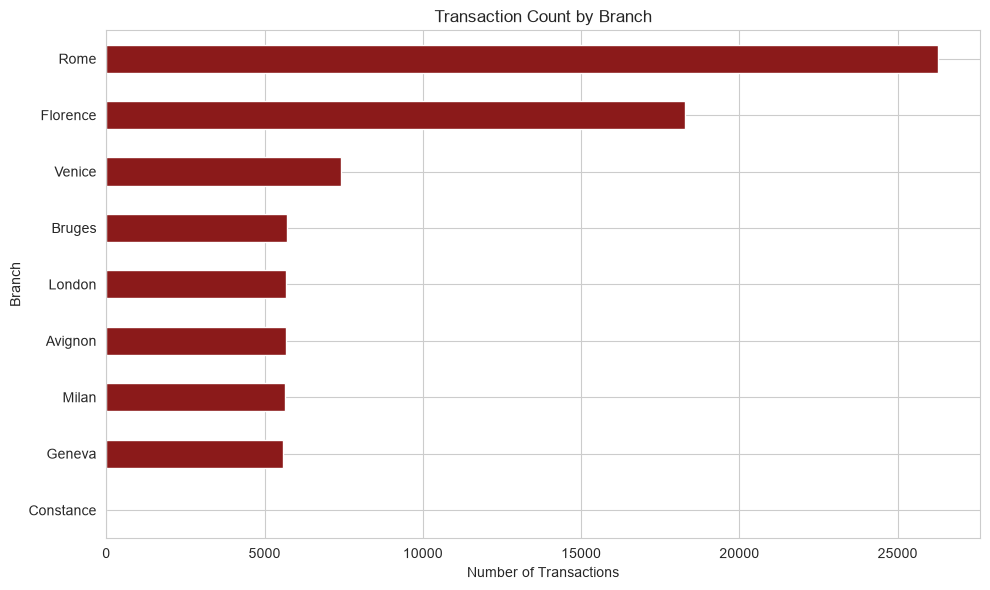

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

branch_summary.sort_values("transaction_count").plot(
    kind="barh",
    y="transaction_count",
    legend=False,
    figsize=(10, 6),
    color="#8B1A1A",
)

plt.title("Transaction Count by Branch")
plt.xlabel("Number of Transactions")
plt.ylabel("Branch")
plt.tight_layout()
plt.show()

## Transactions by type

Count each transaction type and calculate its share of the complete dataset.

In [6]:
type_summary = df.groupby("type").size().rename("transaction_count").to_frame()
type_summary["percentage"] = type_summary["transaction_count"] / total_transactions * 100
type_summary = type_summary.sort_values("transaction_count", ascending=False)

display(type_summary.style.format({"transaction_count": "{:,}", "percentage": "{:.2f}%"}))
assert round(type_summary["percentage"].sum(), 10) == 100

,transaction_count,percentage
type,,
deposit,"25,031",31.20%
operating_expense,"10,987",13.69%
war_financing,"10,568",13.17%
loan_repayment,"8,170",10.18%
loan_issuance,"7,478",9.32%
bill_of_exchange,"6,428",8.01%
withdrawal,"6,374",7.94%
alum_trade,"5,193",6.47%
ransom_payment,1,0.00%


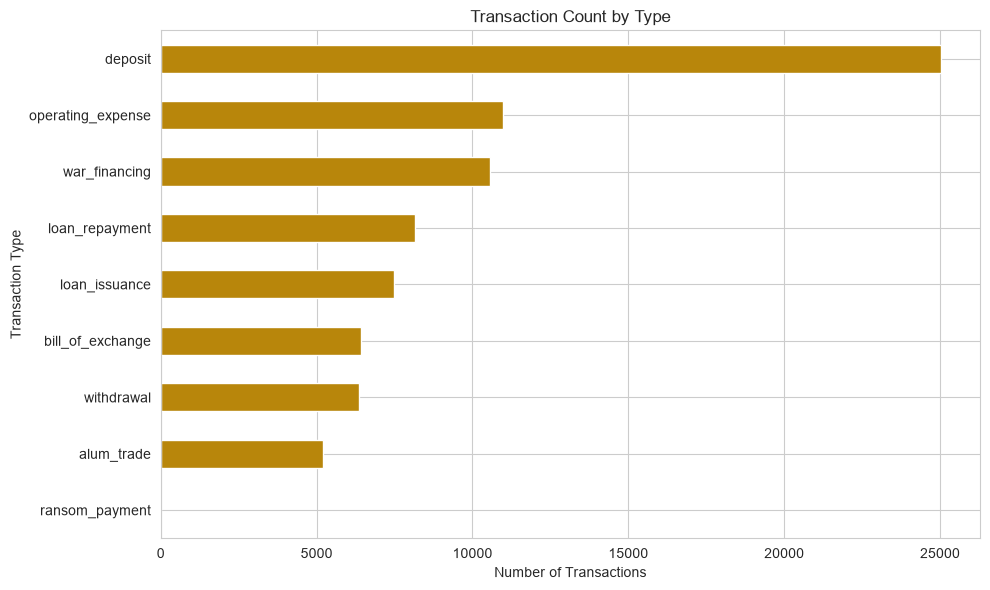

In [9]:
type_summary.sort_values("transaction_count").plot(
    kind="barh",
    y="transaction_count",
    legend=False,
    figsize=(10, 6),
    color="#B8860B",
)

plt.title("Transaction Count by Type")
plt.xlabel("Number of Transactions")
plt.ylabel("Transaction Type")
plt.tight_layout()
plt.show()

## Transaction types within branches

The count table shows segment size. Row percentages show the transaction mix within each branch and control for different branch sizes.

In [7]:
branch_type_counts = pd.crosstab(df["branch"], df["type"])
branch_type_percentages = (
    branch_type_counts.div(branch_type_counts.sum(axis=1), axis=0) * 100
).round(2)

print("Counts")
display(branch_type_counts)
print("Within-branch percentages")
display(branch_type_percentages.style.format("{:.2f}%"))

Counts


type,alum_trade,bill_of_exchange,deposit,loan_issuance,loan_repayment,operating_expense,ransom_payment,war_financing,withdrawal
branch,,,,,,,,,
Avignon,0,791,796,903,1053,1314,0,0,806
Bruges,0,769,801,941,1061,1313,0,0,815
Constance,0,0,0,0,0,0,1,0,0
Florence,1774,818,788,921,1049,1576,0,10568,801
Geneva,0,837,745,880,1006,1339,0,0,768
London,0,819,776,942,982,1397,0,0,747
Milan,0,768,797,926,1000,1350,0,0,797
Rome,1708,861,19513,1005,1007,1342,0,0,852
Venice,1711,765,815,960,1012,1356,0,0,788


Within-branch percentages


type,alum_trade,bill_of_exchange,deposit,loan_issuance,loan_repayment,operating_expense,ransom_payment,war_financing,withdrawal
branch,,,,,,,,,
Avignon,0.00%,13.97%,14.06%,15.95%,18.59%,23.20%,0.00%,0.00%,14.23%
Bruges,0.00%,13.49%,14.05%,16.51%,18.61%,23.04%,0.00%,0.00%,14.30%
Constance,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,100.00%,0.00%,0.00%
Florence,9.70%,4.47%,4.31%,5.03%,5.73%,8.61%,0.00%,57.76%,4.38%
Geneva,0.00%,15.01%,13.36%,15.78%,18.04%,24.02%,0.00%,0.00%,13.78%
London,0.00%,14.46%,13.70%,16.63%,17.34%,24.67%,0.00%,0.00%,13.19%
Milan,0.00%,13.62%,14.14%,16.42%,17.74%,23.94%,0.00%,0.00%,14.14%
Rome,6.50%,3.28%,74.23%,3.82%,3.83%,5.10%,0.00%,0.00%,3.24%
Venice,23.10%,10.33%,11.00%,12.96%,13.66%,18.31%,0.00%,0.00%,10.64%


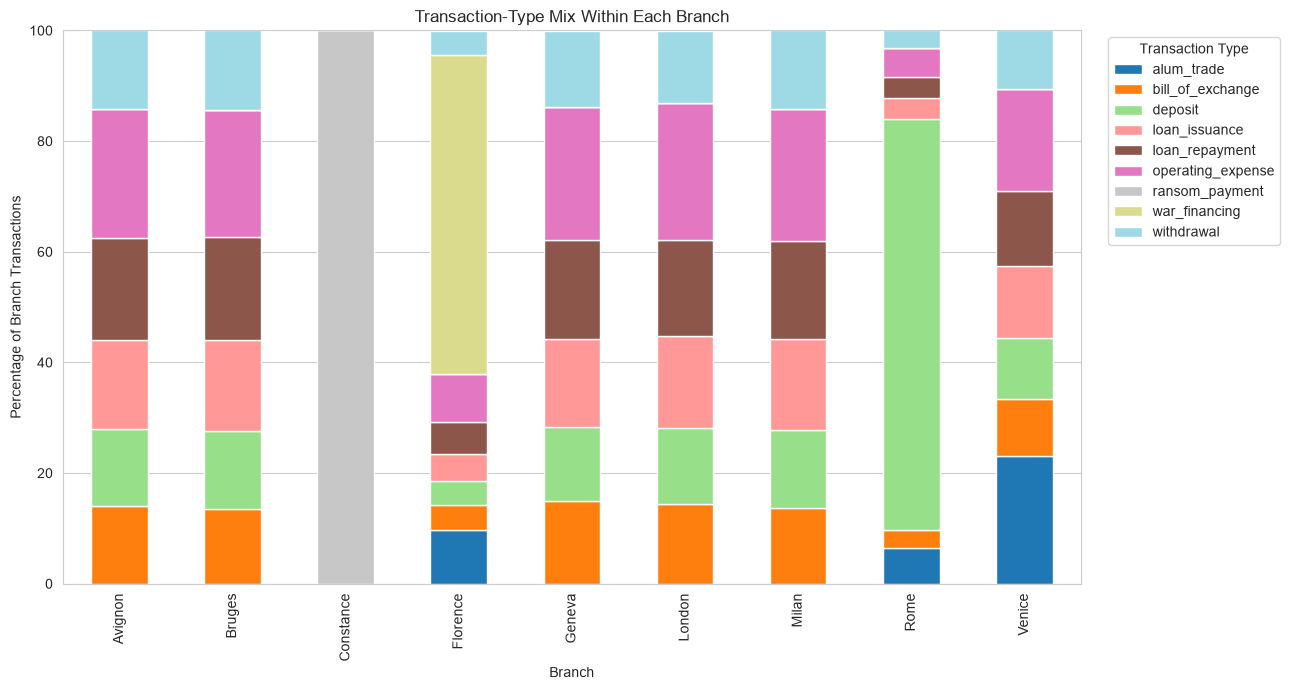

In [10]:
branch_type_percentages.plot(
    kind="bar",
    stacked=True,
    figsize=(13, 7),
    colormap="tab20",
)

plt.title("Transaction-Type Mix Within Each Branch")
plt.xlabel("Branch")
plt.ylabel("Percentage of Branch Transactions")
plt.legend(
    title="Transaction Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
plt.tight_layout()
plt.show()

#Branch/type heatmap
A heatmap provides a compact comparison of every branch/type combination:

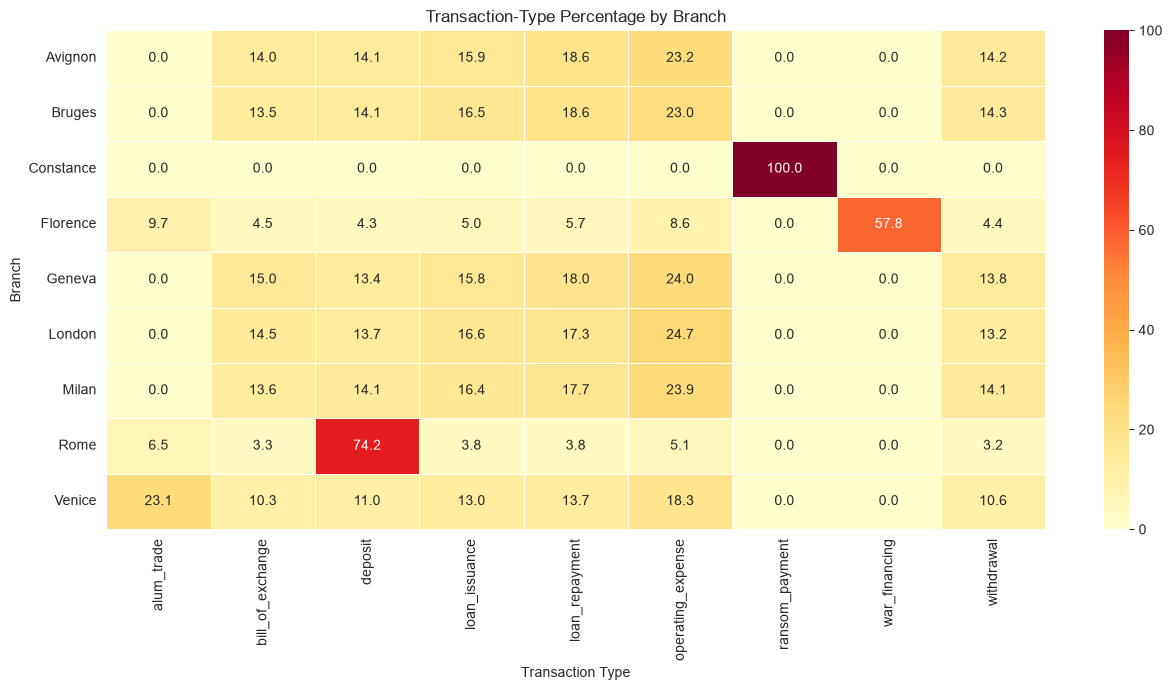

In [12]:
import seaborn as sns

plt.figure(figsize=(13, 7))

sns.heatmap(
    branch_type_percentages,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
)

plt.title("Transaction-Type Percentage by Branch")
plt.xlabel("Transaction Type")
plt.ylabel("Branch")
plt.tight_layout()
plt.show()

#Transaction activity over time
Since the dataset covers 1390–1440, a line chart can reveal long-term changes:

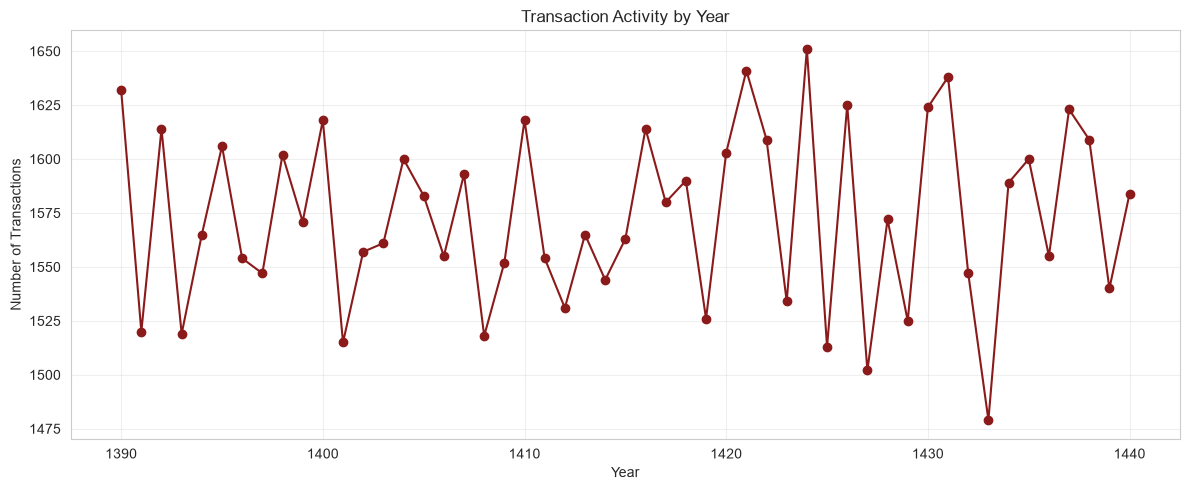

In [13]:
transactions_by_year = (
    df.assign(year=df["date"].dt.year)
    .groupby("year")
    .size()
)

transactions_by_year.plot(
    kind="line",
    figsize=(12, 5),
    marker="o",
    color="#8B1A1A",
)

plt.title("Transaction Activity by Year")
plt.xlabel("Year")
plt.ylabel("Number of Transactions")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#compare branches

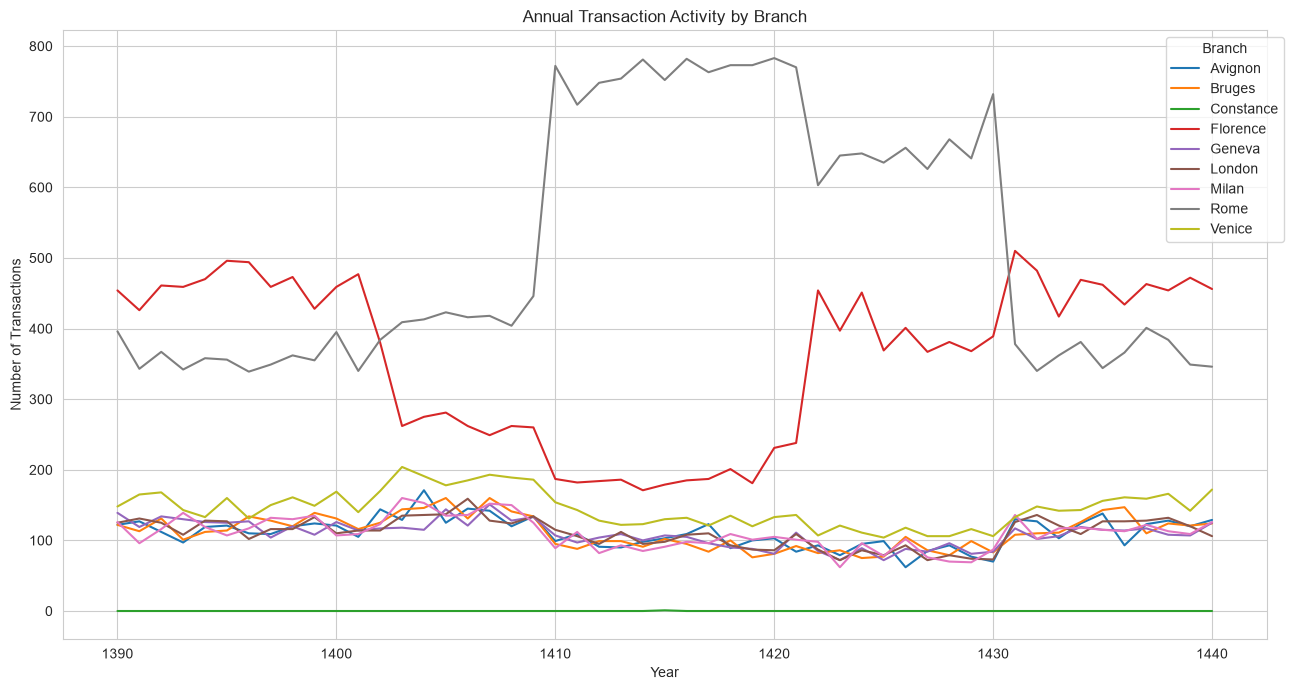

In [14]:
branch_activity_by_year = pd.crosstab(
    df["date"].dt.year,
    df["branch"],
)

branch_activity_by_year.plot(
    kind="line",
    figsize=(13, 7),
)

plt.title("Annual Transaction Activity by Branch")
plt.xlabel("Year")
plt.ylabel("Number of Transactions")
plt.legend(title="Branch", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

Florin volume by branch
Transaction counts and transaction values answer different questions. To compare financial volume:

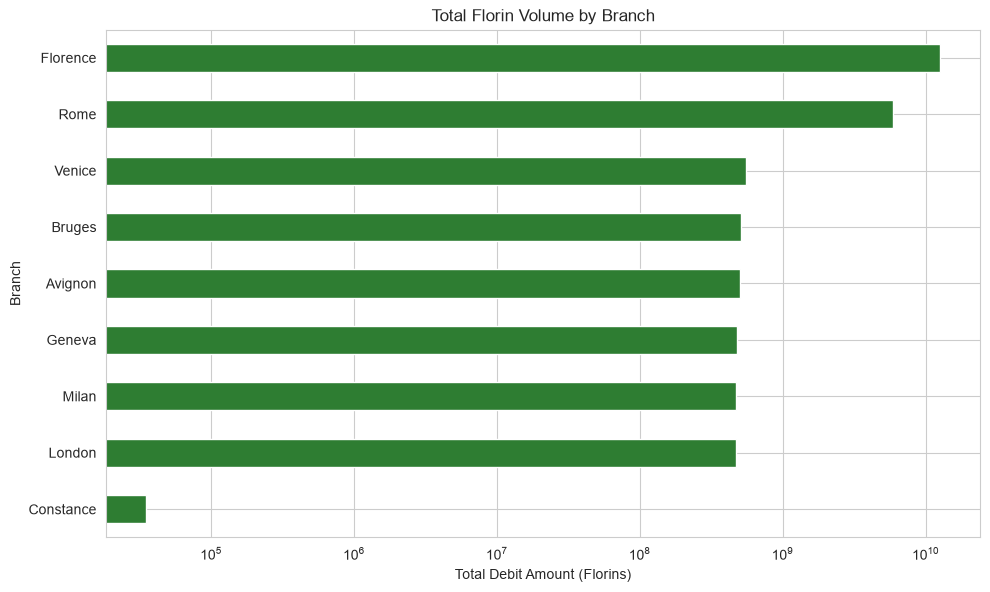

In [17]:
branch_volume = (
    df.groupby("branch")["debit_amount"]
    .sum()
    .sort_values()
)

branch_volume_float = branch_volume.astype(float)

branch_volume_float.plot(
    kind="barh",
    figsize=(10, 6),
    color="#2E7D32",
)

plt.title("Total Florin Volume by Branch")
plt.xlabel("Total Debit Amount (Florins)")
plt.ylabel("Branch")
plt.tight_layout()
plt.xscale("log")
plt.show()

## Highest, lowest, and summary observations

In [8]:
branch_type_long = df.groupby(["branch", "type"]).size().rename("transaction_count").reset_index()
largest_segment = branch_type_long.loc[branch_type_long["transaction_count"].idxmax()]
normal_branches = branch_summary.drop(index="Constance", errors="ignore")
dominant_type_by_branch = branch_type_counts.idxmax(axis=1).to_frame("dominant_type")
dominant_type_by_branch["transaction_count"] = branch_type_counts.max(axis=1)

print(f"Highest-activity branch: {branch_summary.index[0]} ({int(branch_summary.iloc[0]['transaction_count']):,}, {branch_summary.iloc[0]['percentage']:.2f}%)")
print(f"Lowest-activity location: {branch_summary.index[-1]} ({int(branch_summary.iloc[-1]['transaction_count']):,})")
print(f"Lowest normal operating branch: {normal_branches.index[-1]} ({int(normal_branches.iloc[-1]['transaction_count']):,})")
print(f"Most common type: {type_summary.index[0]} ({int(type_summary.iloc[0]['transaction_count']):,}, {type_summary.iloc[0]['percentage']:.2f}%)")
print(f"Least common type: {type_summary.index[-1]} ({int(type_summary.iloc[-1]['transaction_count']):,})")
print(f"Largest branch/type segment: {largest_segment['branch']} / {largest_segment['type']} ({largest_segment['transaction_count']:,})")
display(dominant_type_by_branch.sort_values("transaction_count", ascending=False))

print("\nInterpretation:")
print("- Counts describe transaction frequency, not florin value.")
print("- Within-branch percentages are better than raw counts for comparing each branch's activity mix.")
print("- Constance is a one-event historical location and should be separated from normal operating branches when discussing low activity.")

Highest-activity branch: Rome (26,288, 32.77%)
Lowest-activity location: Constance (1)
Lowest normal operating branch: Geneva (5,575)
Most common type: deposit (25,031, 31.20%)
Least common type: ransom_payment (1)
Largest branch/type segment: Rome / deposit (19,513)


,dominant_type,transaction_count
branch,,
Rome,deposit,19513
Florence,war_financing,10568
Venice,alum_trade,1711
London,operating_expense,1397
Milan,operating_expense,1350
Geneva,operating_expense,1339
Avignon,operating_expense,1314
Bruges,operating_expense,1313
Constance,ransom_payment,1



Interpretation:
- Counts describe transaction frequency, not florin value.
- Within-branch percentages are better than raw counts for comparing each branch's activity mix.
- Constance is a one-event historical location and should be separated from normal operating branches when discussing low activity.
